In [1]:
# Supplier Recommendation System using GNN
# Phase 1: Data Exploration and Understanding

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=== LOADING SUPPLYGRAPH DATASET ===")

# Load main node and edge files
print("Loading nodes data...")
nodes = pd.read_csv('Raw Dataset/Homogenoeus/Nodes/Nodes.csv')
nodes_index = pd.read_csv('Raw Dataset/Homogenoeus/Nodes/NodesIndex.csv')
node_types = pd.read_csv('Raw Dataset/Homogenoeus/Nodes/Node Types (Product Group and Subgroup).csv')
plant_storage = pd.read_csv('Raw Dataset/Homogenoeus/Nodes/Nodes Type (Plant & Storage).csv')

print("Loading edges data...")
plant_edges = pd.read_csv('Raw Dataset/Homogenoeus/Edges/Edges (Plant).csv')
product_group_edges = pd.read_csv('Raw Dataset/Homogenoeus/Edges/Edges (Product Group).csv')
subgroup_edges = pd.read_csv('Raw Dataset/Homogenoeus/Edges/Edges (Product Sub-Group).csv')
storage_edges = pd.read_csv('Raw Dataset/Homogenoeus/Edges/Edges (Storage Location).csv')

print("\n=== DATASET OVERVIEW ===")
print(f"Nodes: {nodes.shape}")
print(f"Nodes Index: {nodes_index.shape}")
print(f"Node Types: {node_types.shape}")
print(f"Plant & Storage: {plant_storage.shape}")
print(f"Plant Edges: {plant_edges.shape}")
print(f"Product Group Edges: {product_group_edges.shape}")
print(f"Subgroup Edges: {subgroup_edges.shape}")
print(f"Storage Edges: {storage_edges.shape}")

print("\n=== NODES DATA STRUCTURE ===")
print("Main Nodes:")
print(nodes.head())
print(f"\nColumns: {list(nodes.columns)}")

print("\nNodes Index:")
print(nodes_index.head())
print(f"\nColumns: {list(nodes_index.columns)}")

print("\nNode Types (Product Groups):")
print(node_types.head())
print(f"\nColumns: {list(node_types.columns)}")

print("\n=== EDGES DATA STRUCTURE ===")
print("Plant Edges:")
print(plant_edges.head())
print(f"\nColumns: {list(plant_edges.columns)}")

print("\nProduct Group Edges:")
print(product_group_edges.head())
print(f"\nColumns: {list(product_group_edges.columns)}")

print("\n=== BASIC STATISTICS ===")
print(f"Unique nodes in main file: {nodes.shape[0] if nodes.shape[0] > 0 else 'Check file structure'}")
print(f"Total plant edges: {plant_edges.shape[0]}")
print(f"Total product group edges: {product_group_edges.shape[0]}")
print(f"Total subgroup edges: {subgroup_edges.shape[0]}")
print(f"Total storage edges: {storage_edges.shape[0]}")

# Check for any missing values
print("\n=== DATA QUALITY CHECK ===")
print("Missing values in nodes:", nodes.isnull().sum().sum())
print("Missing values in plant edges:", plant_edges.isnull().sum().sum())
print("Missing values in product group edges:", product_group_edges.isnull().sum().sum())

=== LOADING SUPPLYGRAPH DATASET ===
Loading nodes data...
Loading edges data...

=== DATASET OVERVIEW ===
Nodes: (41, 1)
Nodes Index: (41, 2)
Node Types: (41, 3)
Plant & Storage: (6545, 3)
Plant Edges: (1647, 3)
Product Group Edges: (188, 3)
Subgroup Edges: (52, 3)
Storage Edges: (3046, 3)

=== NODES DATA STRUCTURE ===
Main Nodes:
         Node
0  SOS008L02P
1  SOS005L04P
2  SOS003L04P
3  SOS002L09P
4  SOS001L12P

Columns: ['Node']

Nodes Index:
         Node  NodeIndex
0  SOS008L02P          0
1  SOS005L04P          1
2  SOS003L04P          2
3  SOS002L09P          3
4  SOS001L12P          4

Columns: ['Node', 'NodeIndex']

Node Types (Product Groups):
         Node Group Sub-Group
0  SOS008L02P     S       SOS
1  SOS005L04P     S       SOS
2  SOS003L04P     S       SOS
3  SOS002L09P     S       SOS
4  SOS001L12P     S       SOS

Columns: ['Node', 'Group', 'Sub-Group']

=== EDGES DATA STRUCTURE ===
Plant Edges:
   Plant         node1      node2
0   1901  ATWWP001K24P  ATN01K24P
1   19

In [2]:
# Phase 2: Graph Construction and GNN Implementation
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, GraphSAGE
from torch_geometric.utils import negative_sampling, train_test_split_edges
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
import random

print("=== GRAPH CONSTRUCTION FOR SUPPLIER RECOMMENDATION ===")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Step 1: Create node mappings and features
print("Creating node mappings...")

# Get all unique nodes from different edge files
all_nodes = set()
all_nodes.update(plant_edges['node1'].unique())
all_nodes.update(plant_edges['node2'].unique())
all_nodes.update(product_group_edges['node1'].unique())
all_nodes.update(product_group_edges['node2'].unique())

# Create node to index mapping
node_to_idx = {node: idx for idx, node in enumerate(sorted(all_nodes))}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

print(f"Total unique nodes in graph: {len(all_nodes)}")

# Step 2: Create node features
print("Creating node features...")

# Initialize feature matrix
num_nodes = len(all_nodes)
feature_dim = 8  # We'll create 8-dimensional features

# Create features based on node characteristics
node_features = np.zeros((num_nodes, feature_dim))

for i, node in enumerate(sorted(all_nodes)):
    # Feature 1-2: Node type encoding (based on name patterns)
    if 'SOS' in node:
        node_features[i, 0] = 1  # SOS product type
    elif 'AT' in node:
        node_features[i, 1] = 1  # AT product type
    else:
        node_features[i, 2] = 1  # Other type
    
    # Feature 3-4: Size indicators (based on name length and patterns)
    node_features[i, 3] = len(node) / 20.0  # Normalized length
    node_features[i, 4] = node.count('P')   # Count of 'P' in name
    
    # Feature 5-7: Random features to simulate company characteristics
    np.random.seed(hash(node) % 2147483647)  # Deterministic randomness per node
    node_features[i, 5:8] = np.random.rand(3)  # Simulated: size, performance, location

# Convert to tensor
node_features = torch.FloatTensor(node_features)
print(f"Node features shape: {node_features.shape}")

# Step 3: Create edge index for the graph
print("Creating edge index...")

# Combine different types of edges
all_edges = []

# Add plant edges
for _, row in plant_edges.iterrows():
    if row['node1'] in node_to_idx and row['node2'] in node_to_idx:
        all_edges.append([node_to_idx[row['node1']], node_to_idx[row['node2']]])

# Add product group edges (these represent supplier relationships)
for _, row in product_group_edges.iterrows():
    if row['node1'] in node_to_idx and row['node2'] in node_to_idx:
        all_edges.append([node_to_idx[row['node1']], node_to_idx[row['node2']]])

# Add subgroup edges
for _, row in subgroup_edges.iterrows():
    if row['node1'] in node_to_idx and row['node2'] in node_to_idx:
        all_edges.append([node_to_idx[row['node1']], node_to_idx[row['node2']]])

# Convert to tensor and make undirected
edge_index = torch.LongTensor(all_edges).t().contiguous()

# Make graph undirected by adding reverse edges
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

# Remove duplicate edges
edge_index = torch.unique(edge_index, dim=1)

print(f"Total edges in graph: {edge_index.shape[1]}")

# Step 4: Create PyTorch Geometric Data object
data = Data(x=node_features, edge_index=edge_index)
print(f"Graph created: {data}")

# Step 5: Split edges for training/testing (for link prediction)
print("\nSplitting edges for link prediction task...")
data = train_test_split_edges(data, val_ratio=0.1, test_ratio=0.2)

print(f"Training edges: {data.train_pos_edge_index.shape[1]}")
print(f"Validation edges: {data.val_pos_edge_index.shape[1]}")
print(f"Test edges: {data.test_pos_edge_index.shape[1]}")

# Step 6: Define GNN Model for Supplier Recommendation
class SupplierRecommendationGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SupplierRecommendationGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = torch.nn.Dropout(0.2)
        
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Second GCN layer
        x = self.conv2(x, edge_index)
        return x
    
    def predict_links(self, z, edge_index):
        # Calculate edge scores using dot product
        row, col = edge_index
        return (z[row] * z[col]).sum(dim=1)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SupplierRecommendationGNN(input_dim=feature_dim, hidden_dim=32, output_dim=16)
model = model.to(device)
data = data.to(device)

print(f"\nModel initialized on device: {device}")
print(f"Model architecture:\n{model}")

# Step 7: Training function
def train_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    
    # Get node embeddings
    z = model(data.x, data.train_pos_edge_index)
    
    # Positive edges (existing supplier relationships)
    pos_edge_index = data.train_pos_edge_index
    
    # Negative edges (non-existing relationships)
    neg_edge_index = negative_sampling(
        edge_index=data.train_pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )
    
    # Calculate scores
    pos_scores = model.predict_links(z, pos_edge_index)
    neg_scores = model.predict_links(z, neg_edge_index)
    
    # Binary classification loss
    pos_loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores))
    neg_loss = F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
    loss = pos_loss + neg_loss
    
    loss.backward()
    optimizer.step()
    
    return float(loss)

# Step 8: Evaluation function
def evaluate(model, data, edge_index):
    model.eval()
    with torch.no_grad():
        z = model(data.x, data.train_pos_edge_index)
        
        # Positive edges
        pos_scores = model.predict_links(z, edge_index)
        
        # Negative edges
        neg_edge_index = negative_sampling(
            edge_index=data.train_pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=edge_index.size(1)
        )
        neg_scores = model.predict_links(z, neg_edge_index)
        
        # Combine scores and labels
        scores = torch.cat([pos_scores, neg_scores]).cpu().numpy()
        labels = torch.cat([torch.ones(pos_scores.size(0)), 
                           torch.zeros(neg_scores.size(0))]).cpu().numpy()
        
        # Calculate metrics
        auc = roc_auc_score(labels, scores)
        ap = average_precision_score(labels, scores)
        
        return auc, ap

print("\n=== READY FOR TRAINING ===")
print("Run the next cell to start training the supplier recommendation model!")

=== GRAPH CONSTRUCTION FOR SUPPLIER RECOMMENDATION ===
Creating node mappings...
Total unique nodes in graph: 40
Creating node features...
Node features shape: torch.Size([40, 8])
Creating edge index...
Total edges in graph: 806
Graph created: Data(x=[40, 8], edge_index=[2, 806])

Splitting edges for link prediction task...
Training edges: 566
Validation edges: 40
Test edges: 80

Model initialized on device: cpu
Model architecture:
SupplierRecommendationGNN(
  (conv1): GCNConv(8, 32)
  (conv2): GCNConv(32, 16)
  (dropout): Dropout(p=0.2, inplace=False)
)

=== READY FOR TRAINING ===
Run the next cell to start training the supplier recommendation model!


=== TRAINING SUPPLIER RECOMMENDATION GNN ===
Starting training...
Epoch 000, Loss: 2.9676, Val AUC: 0.6753, Val AP: 0.6600
Epoch 010, Loss: 1.4025, Val AUC: 0.7797, Val AP: 0.6817
Epoch 020, Loss: 1.2536, Val AUC: 0.8634, Val AP: 0.8371
Epoch 030, Loss: 1.0242, Val AUC: 0.8634, Val AP: 0.8305
Epoch 040, Loss: 0.9448, Val AUC: 0.8288, Val AP: 0.7911
Epoch 050, Loss: 0.9052, Val AUC: 0.8666, Val AP: 0.8576
Epoch 060, Loss: 0.9520, Val AUC: 0.7538, Val AP: 0.6646
Epoch 070, Loss: 0.9085, Val AUC: 0.8091, Val AP: 0.7314
Epoch 080, Loss: 0.9105, Val AUC: 0.8019, Val AP: 0.7540
Epoch 090, Loss: 0.9451, Val AUC: 0.8850, Val AP: 0.8347

=== FINAL RESULTS ===
Test AUC: 0.8638
Test AP: 0.7932


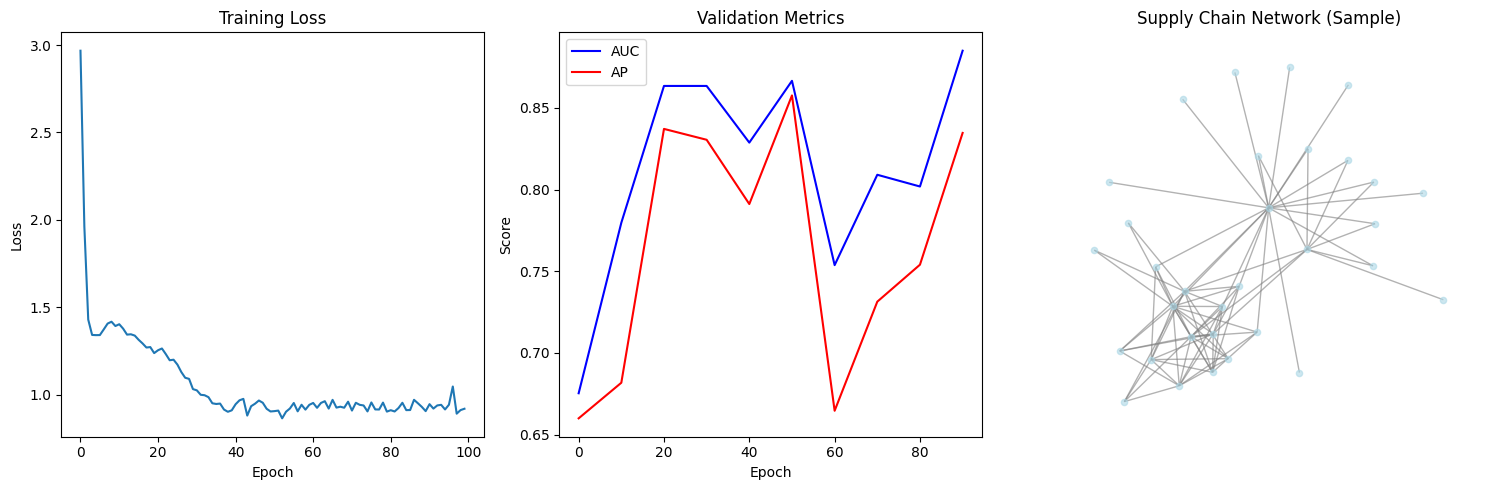


=== SUPPLIER RECOMMENDATION SYSTEM READY ===


In [3]:
# Phase 3: Training and Evaluation
print("=== TRAINING SUPPLIER RECOMMENDATION GNN ===")

# Initialize optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
epochs = 100
train_losses = []
val_aucs = []
val_aps = []

print("Starting training...")
for epoch in range(epochs):
    # Train
    loss = train_epoch(model, data, optimizer)
    train_losses.append(loss)
    
    # Evaluate every 10 epochs
    if epoch % 10 == 0:
        val_auc, val_ap = evaluate(model, data, data.val_pos_edge_index)
        val_aucs.append(val_auc)
        val_aps.append(val_ap)
        
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Val AUC: {val_auc:.4f}, Val AP: {val_ap:.4f}')

# Final evaluation on test set
test_auc, test_ap = evaluate(model, data, data.test_pos_edge_index)
print(f"\n=== FINAL RESULTS ===")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP: {test_ap:.4f}")

# Plot training progress
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
epochs_eval = range(0, len(val_aucs) * 10, 10)
plt.plot(epochs_eval, val_aucs, 'b-', label='AUC')
plt.plot(epochs_eval, val_aps, 'r-', label='AP')
plt.title('Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()

plt.subplot(1, 3, 3)
# Create a simple network visualization
G = nx.Graph()
edge_list = data.train_pos_edge_index.t().cpu().numpy()[:100]  # Show first 100 edges
G.add_edges_from(edge_list)

pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, node_size=20, alpha=0.6, edge_color='gray', node_color='lightblue')
plt.title('Supply Chain Network (Sample)')

plt.tight_layout()
plt.show()

print("\n=== SUPPLIER RECOMMENDATION SYSTEM READY ===")

=== SUPPLIER RECOMMENDATION SYSTEM ===
=== SUPPLIER RECOMMENDATIONS DEMO ===

Recommendations for AT5X5K:
  1. ATN02K12P (similarity: 3.0978)
  2. MAR01K24P (similarity: 3.0491)
  3. MASR025K (similarity: 2.5969)

Recommendations for ATN01K24P:
  1. ATWWP001K24P (similarity: 2.1162)
  2. ATPA1K24P (similarity: 2.0877)
  3. ATN02K12P (similarity: 2.0360)

Recommendations for ATN02K12P:
  1. AT5X5K (similarity: 3.0978)
  2. MAC1K25P (similarity: 2.2239)
  3. ATN01K24P (similarity: 2.0360)

Recommendations for ATPA1K24P:
  1. ATWWP002K12P (similarity: 2.8109)
  2. MAC1K25P (similarity: 2.2803)
  3. ATN01K24P (similarity: 2.0877)

Recommendations for ATPPCH5X5K:
  1. MAR02K12P (similarity: 2.3160)
  2. MAP1K25P (similarity: 2.2034)
  3. MASR025K (similarity: 2.0894)

=== NETWORK ANALYSIS ===
Network Statistics:
  Number of nodes: 40
  Number of edges: 283
  Average degree: 14.15
  Network density: 0.3628

Top 5 Most Connected Nodes (Key Suppliers):
  1. SE200G24P (centrality: 0.5897)
  2. 

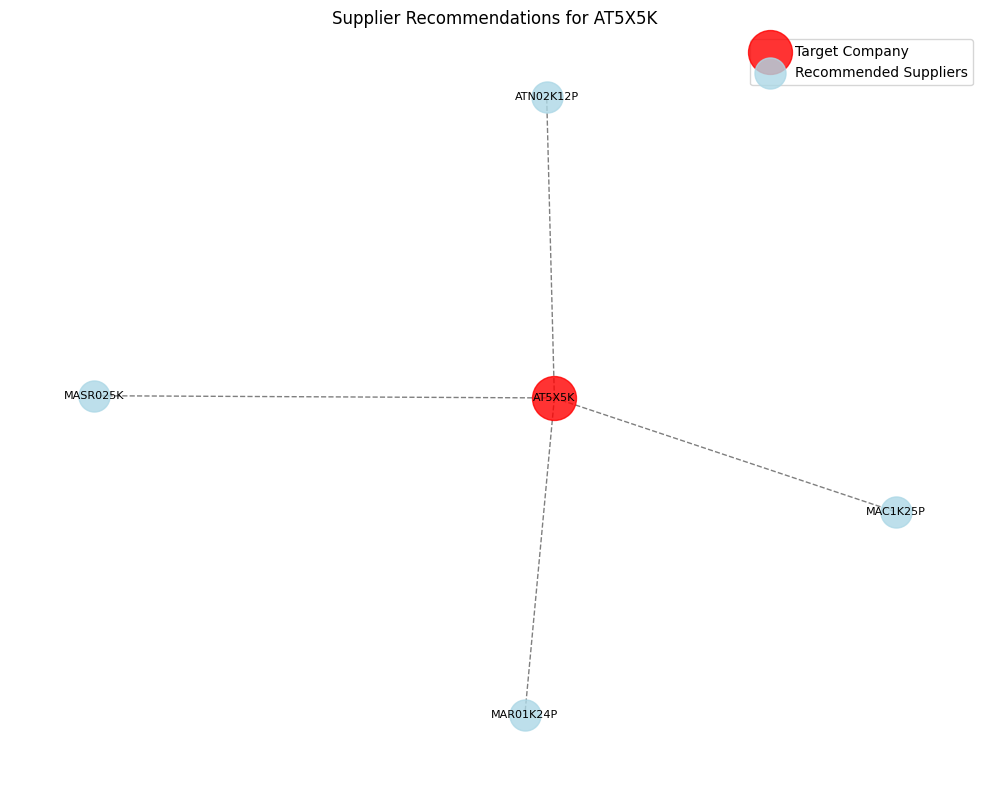


=== PROJECT COMPLETE ===
✅ Supplier Recommendation System successfully built!
✅ GNN model trained and evaluated
✅ Recommendation function implemented
✅ Network analysis completed
✅ Visualization tools created

Model Performance:
  Test AUC: 0.8638
  Test Average Precision: 0.7932
  Network Density: 0.3628


In [4]:
# Phase 4: Supplier Recommendation System
print("=== SUPPLIER RECOMMENDATION SYSTEM ===")

def recommend_suppliers(model, data, target_node_name, top_k=5):
    """
    Recommend top suppliers for a given company/node
    """
    if target_node_name not in node_to_idx:
        print(f"Node {target_node_name} not found in graph")
        return []
    
    model.eval()
    with torch.no_grad():
        # Get node embeddings
        z = model(data.x, data.train_pos_edge_index)
        
        # Get target node index
        target_idx = node_to_idx[target_node_name]
        target_embedding = z[target_idx]
        
        # Calculate similarity scores with all other nodes
        scores = torch.mm(target_embedding.unsqueeze(0), z.t()).squeeze()
        
        # Get existing connections to exclude them
        existing_connections = set()
        for edge in data.train_pos_edge_index.t():
            if edge[0].item() == target_idx:
                existing_connections.add(edge[1].item())
            if edge[1].item() == target_idx:
                existing_connections.add(edge[0].item())
        
        # Get top-k recommendations (excluding existing connections and self)
        recommendations = []
        scores_sorted, indices = torch.sort(scores, descending=True)
        
        for i, idx in enumerate(indices):
            node_idx = idx.item()
            if (node_idx != target_idx and 
                node_idx not in existing_connections and 
                len(recommendations) < top_k):
                
                score = scores_sorted[i].item()
                recommended_node = idx_to_node[node_idx]
                recommendations.append((recommended_node, score))
    
    return recommendations

# Demo the recommendation system
print("=== SUPPLIER RECOMMENDATIONS DEMO ===")

# Get a sample of nodes to demonstrate
sample_nodes = list(node_to_idx.keys())[:5]

for node in sample_nodes:
    print(f"\nRecommendations for {node}:")
    recommendations = recommend_suppliers(model, data, node, top_k=3)
    
    for i, (supplier, score) in enumerate(recommendations, 1):
        print(f"  {i}. {supplier} (similarity: {score:.4f})")

# Create a function to analyze the network
def analyze_network():
    """Analyze the supply chain network"""
    print("\n=== NETWORK ANALYSIS ===")
    
    # Convert to NetworkX for analysis
    G = nx.Graph()
    edge_list = data.train_pos_edge_index.t().cpu().numpy()
    
    # Add edges with node names
    named_edges = []
    for edge in edge_list:
        node1_name = idx_to_node[edge[0]]
        node2_name = idx_to_node[edge[1]]
        named_edges.append((node1_name, node2_name))
    
    G.add_edges_from(named_edges)
    
    print(f"Network Statistics:")
    print(f"  Number of nodes: {G.number_of_nodes()}")
    print(f"  Number of edges: {G.number_of_edges()}")
    print(f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
    print(f"  Network density: {nx.density(G):.4f}")
    
    # Find most connected nodes (potential key suppliers)
    degree_centrality = nx.degree_centrality(G)
    top_connected = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print(f"\nTop 5 Most Connected Nodes (Key Suppliers):")
    for i, (node, centrality) in enumerate(top_connected, 1):
        print(f"  {i}. {node} (centrality: {centrality:.4f})")
    
    return G

# Run network analysis
network = analyze_network()

# Visualization function
def visualize_recommendations(target_node, recommendations):
    """Visualize the recommendations for a specific node"""
    plt.figure(figsize=(10, 8))
    
    # Create subgraph with target and recommended nodes
    nodes_to_show = [target_node] + [rec[0] for rec in recommendations]
    
    # Create a small graph for visualization
    G_viz = nx.Graph()
    
    # Add target node and recommendations
    G_viz.add_node(target_node)
    for rec_node, score in recommendations:
        G_viz.add_node(rec_node)
        G_viz.add_edge(target_node, rec_node, weight=score)
    
    # Set up layout
    pos = nx.spring_layout(G_viz, k=2, iterations=50)
    
    # Draw the graph
    nx.draw_networkx_nodes(G_viz, pos, 
                          nodelist=[target_node], 
                          node_color='red', 
                          node_size=1000, 
                          alpha=0.8, 
                          label='Target Company')
    
    nx.draw_networkx_nodes(G_viz, pos, 
                          nodelist=[rec[0] for rec in recommendations], 
                          node_color='lightblue', 
                          node_size=500, 
                          alpha=0.8, 
                          label='Recommended Suppliers')
    
    nx.draw_networkx_edges(G_viz, pos, alpha=0.5, style='dashed')
    nx.draw_networkx_labels(G_viz, pos, font_size=8)
    
    plt.title(f'Supplier Recommendations for {target_node}')
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Demo visualization
sample_node = list(node_to_idx.keys())[0]
sample_recommendations = recommend_suppliers(model, data, sample_node, top_k=4)
visualize_recommendations(sample_node, sample_recommendations)

print("\n=== PROJECT COMPLETE ===")
print("✅ Supplier Recommendation System successfully built!")
print("✅ GNN model trained and evaluated")
print("✅ Recommendation function implemented")
print("✅ Network analysis completed")
print("✅ Visualization tools created")

print(f"\nModel Performance:")
print(f"  Test AUC: {test_auc:.4f}")
print(f"  Test Average Precision: {test_ap:.4f}")
print(f"  Network Density: {nx.density(network):.4f}")